# OCR Quality Inspection Notebook

This notebook is a manual inspection workflow for PolyDocBench OCR experiments.

Use it to:

1. Select an experiment artifact by language, article, template, page, and noise profile.
2. Load one noisy scan and its transformed GT.
3. Run Tesseract on the image.
4. Compute OCR quality metrics against the transformed GT.
5. Visualize transformed GT polygons and Tesseract predictions on the scan.

The notebook is especially useful for checking affine scan noise such as `medium_scan_0.jpg` or `heavy_scan_0.jpg`, where GT coordinates must be compared in image pixel coordinates.


## 1. Environment Setup

Run this notebook from the repository root or from the `notebooks/` directory. The cell below detects the project root and imports PolyDocBench modules.

In [1]:
from __future__ import annotations

import json
import shutil
import sys
from pathlib import Path

from PIL import Image, ImageDraw

try:
    from IPython.display import Image as IPyImage
    from IPython.display import Markdown, display
except ImportError:
    def display(value):
        print(value)

    def Markdown(value):
        return value

    class IPyImage:
        def __init__(self, filename: str):
            self.filename = filename

        def __repr__(self) -> str:
            return self.filename

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: e:\PolyDocBench


## 2. Experiment Configuration

The experiment pipeline stores artifacts using this hierarchy:

```text
outputs/experiments/tesseract_quality/<language>/<article>/<template>/noisy/page_<NNN>/<noise_profile>_<variant>.jpg
```

Change the selection below to inspect another result. `NOISE_PROFILE` selects the level of scan noise:

- `light_scan`: resolution, illumination, and compression noise.
- `medium_scan`: includes affine/rotation noise and is recommended for transformed-GT checks.
- `heavy_scan`: stronger scan noise including affine/rotation effects.


In [2]:
LANGUAGE_CODE = "en"
ARTICLE_ID = "quantum_mechanics"
TEMPLATE = "simple_article"
PAGE_NUMBER = 1
NOISE_PROFILE = "medium_scan"
VARIANT = 0

AVAILABLE_NOISE_PROFILES = ("light_scan", "medium_scan", "heavy_scan")
assert NOISE_PROFILE in AVAILABLE_NOISE_PROFILES, f"Unknown noise profile: {NOISE_PROFILE}"
assert PAGE_NUMBER >= 1, "PAGE_NUMBER is one-based and must be positive"

EXPERIMENT_ROOT = PROJECT_ROOT / "outputs" / "experiments" / "tesseract_quality"
CASE_ROOT = EXPERIMENT_ROOT / LANGUAGE_CODE / ARTICLE_ID / TEMPLATE
PAGE_DIR = f"page_{PAGE_NUMBER:03d}"
ARTIFACT_STEM = f"{NOISE_PROFILE}_{VARIANT}"
SCAN_PATH = CASE_ROOT / "noisy" / PAGE_DIR / f"{ARTIFACT_STEM}.jpg"
GT_PATH = CASE_ROOT / "noisy" / PAGE_DIR / f"{ARTIFACT_STEM}_gt.json"
PREDICTION_PATH = CASE_ROOT / "predictions" / PAGE_DIR / f"{ARTIFACT_STEM}_tesseract.json"
OVERLAY_PATH = CASE_ROOT / "debug" / PAGE_DIR / f"{ARTIFACT_STEM}_quality_overlay.jpg"

# Tesseract language code. Examples: eng, rus, fra, deu, spa, ita.
TESSERACT_LANG_BY_CASE = {
    "en": "eng",
    "ru": "rus",
    "fr": "fra",
    "de": "deu",
    "es": "spa",
    "it": "ita",
}
TESSERACT_LANG = TESSERACT_LANG_BY_CASE.get(LANGUAGE_CODE, "eng")

# If Python cannot find tesseract through PATH, set the executable explicitly.
TESSERACT_CMD = shutil.which("tesseract") or r"C:\Program Files\Tesseract-OCR\tesseract.exe"

print("Article:", ARTICLE_ID)
print("Template:", TEMPLATE)
print("Page:", PAGE_NUMBER)
print("Noise profile:", NOISE_PROFILE)
print("Scan:", SCAN_PATH)
print("GT:", GT_PATH)
print("Predictions:", PREDICTION_PATH)
print("Overlay:", OVERLAY_PATH)
print("Tesseract:", TESSERACT_CMD)
print("Tesseract language:", TESSERACT_LANG)


Article: quantum_mechanics
Template: simple_article
Page: 1
Noise profile: medium_scan
Scan: e:\PolyDocBench\outputs\experiments\tesseract_quality\en\quantum_mechanics\simple_article\noisy\page_001\medium_scan_0.jpg
GT: e:\PolyDocBench\outputs\experiments\tesseract_quality\en\quantum_mechanics\simple_article\noisy\page_001\medium_scan_0_gt.json
Predictions: e:\PolyDocBench\outputs\experiments\tesseract_quality\en\quantum_mechanics\simple_article\predictions\page_001\medium_scan_0_tesseract.json
Overlay: e:\PolyDocBench\outputs\experiments\tesseract_quality\en\quantum_mechanics\simple_article\debug\page_001\medium_scan_0_quality_overlay.jpg
Tesseract: C:\Program Files\Tesseract-OCR\tesseract.EXE
Tesseract language: eng


## 3. Load Scan And Transformed GT

For noisy scans, GT must use image coordinates:

- unit: `pixels`
- origin: `top-left`

The `transform.matrix` describes how source PDF bboxes were mapped into the noisy image. `polygon` stores the transformed four-corner geometry; `bbox` stores the horizontal box around that polygon.

In [3]:
from polydocbench.eval import extract_gt_lines, load_gt

assert SCAN_PATH.exists(), f"Scan image was not found: {SCAN_PATH}"
assert GT_PATH.exists(), f"GT file was not found: {GT_PATH}"

scan = Image.open(SCAN_PATH).convert("RGB")
gt = load_gt(GT_PATH)
metadata = gt.get("metadata", {})
coordinate_system = metadata.get("coordinate_system", {})
transform = metadata.get("transform", {})

display(Markdown(f"**Image size:** {scan.width} x {scan.height}"))
display(Markdown(f"**GT coordinate system:** `{coordinate_system}`"))
display(Markdown(f"**Transform:** `{transform}`"))

assert coordinate_system.get("unit") == "pixels", "Expected noisy GT in pixel coordinates"
assert coordinate_system.get("origin") == "top-left", "Expected noisy GT with top-left origin"

gt_lines = extract_gt_lines(gt, page_number=1)
print(f"GT lines: {len(gt_lines)}")
print("First GT line:")
print(json.dumps(gt_lines[0], ensure_ascii=False, indent=2) if gt_lines else "No GT lines")

**Image size:** 1654 x 2339

**GT coordinate system:** `{'unit': 'pixels', 'origin': 'top-left', 'image_width': 1654, 'image_height': 2339}`

**Transform:** `{'type': 'affine', 'matrix': [[0.9996149637162974, -0.0036807355920723747, 32.76913802043535], [0.027747510058839957, 0.9996149637162974, -22.496890884870492]]}`

GT lines: 47
First GT line:
{
  "id": "paragraph_0001_line_001",
  "type": "text_line",
  "text": "For a more accessible and less technical introduction to this topic, see Introduction to quan-",
  "bbox": {
    "x": 240.38794202763015,
    "y": 122.23032033395317,
    "width": 1305.1755604826797,
    "height": 69.5464147006954
  },
  "page_number": 1,
  "container_id": "page_1_image"
}


## 4. Run Tesseract

The important detail is `coordinate_system="image"`: Tesseract bboxes are kept in top-left pixel coordinates, so they can be compared directly with noisy GT.

In [4]:
import pytesseract

from polydocbench.eval.ocr import extract_tesseract_lines

if TESSERACT_CMD:
    pytesseract.pytesseract.tesseract_cmd = str(TESSERACT_CMD)

ocr_lines = extract_tesseract_lines(
    SCAN_PATH,
    lang=TESSERACT_LANG,
    page_number=1,
    coordinate_system="image",
)

PREDICTION_PATH.parent.mkdir(parents=True, exist_ok=True)
PREDICTION_PATH.write_text(json.dumps(ocr_lines, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"OCR lines: {len(ocr_lines)}")
print(f"Saved predictions: {PREDICTION_PATH}")
print("First OCR line:")
print(json.dumps(ocr_lines[0], ensure_ascii=False, indent=2) if ocr_lines else "No OCR lines")

OCR lines: 36
Saved predictions: e:\PolyDocBench\outputs\experiments\tesseract_quality\en\quantum_mechanics\simple_article\predictions\page_001\medium_scan_0_tesseract.json
First OCR line:
{
  "id": "ocr_line_0",
  "type": "text_line",
  "text": "For a more accessible and",
  "bbox": {
    "x": 243.0,
    "y": 124.0,
    "width": 367.0,
    "height": 32.0
  },
  "confidence": 95.2,
  "page_number": 1
}


## 5. Compute OCR Quality Metrics

Metrics are computed with PolyDocBench line matching:

- `CER`: character error rate, lower is better.
- `WER`: word error rate, lower is better.
- `IoU`: average matched bbox overlap, higher is better.
- `matched_ratio`: share of GT lines matched to OCR lines by IoU.

Current quality evaluation is bbox-based. For rotated GT, the evaluator uses the axis-aligned `bbox` that encloses the transformed `polygon`.

In [5]:
from polydocbench.eval import evaluate_ocr_quality

IOU_THRESHOLD = 0.3

metrics = evaluate_ocr_quality(gt_lines, ocr_lines, iou_threshold=IOU_THRESHOLD)
metrics


{'CER': 0.5976233329362386,
 'WER': 0.6247322630490735,
 'IoU': 0.32803207919468275,
 'matched_ratio': 0.574468085106383}

## 6. Inspect Line Matches

By default this cell prints all matched GT lines. Set `MAX_MATCHES_TO_PRINT` to an integer if you want a shorter preview.

If the overlay shows OCR boxes farther down the image but this cell does not print them, check this limit first.

In [6]:
from polydocbench.eval.matching import match_lines

# Use None to print all GT lines. Set, for example, 20 for a short preview.
MAX_MATCHES_TO_PRINT = None

matches = match_lines(gt_lines, ocr_lines, iou_threshold=IOU_THRESHOLD)
matches_to_print = matches if MAX_MATCHES_TO_PRINT is None else matches[:MAX_MATCHES_TO_PRINT]

print(f"Total GT lines: {len(gt_lines)}")
print(f"Total OCR lines: {len(ocr_lines)}")
print(f"Total matches to inspect: {len(matches_to_print)}")

for index, match in enumerate(matches_to_print, start=1):
    pred_text = match.prediction["text"] if match.prediction else "<NO MATCH>"
    print(f"--- Match {index} | IoU={match.iou:.3f}")
    print("GT  :", match.gt["text"])
    print("OCR :", pred_text)


Total GT lines: 47
Total OCR lines: 36
Total matches to inspect: 47
--- Match 1 | IoU=0.516
GT  : For a more accessible and less technical introduction to this topic, see Introduction to quan-
OCR : less technical introduction to this topic, see Introduction to quan-
--- Match 2 | IoU=0.648
GT  : tum mechanics.
OCR : tum mechanics.
--- Match 3 | IoU=0.334
GT  : Quantum mechanics is the fundamental physical theory that describes the behavior of mat-
OCR : Quantum mechanics is the fundamental physical
--- Match 4 | IoU=0.518
GT  : ter and of light; its unusual characteristics typically occur at and below the scale of atoms.: 1.1 It
OCR : ter and of light; its unusual characteristics typically occur at and below th
--- Match 5 | IoU=0.962
GT  : is the foundation of all quantum physics, which includes quantum chemistry, quantum biology,
OCR : i ics, ich i quantum chemistry, quantum biology,
--- Match 6 | IoU=0.907
GT  : quantum field theory, quantum technology, and quantum information scie

## 7. Visualize GT And OCR Predictions

Color convention:

- Red: transformed GT polygon.
- Green: Tesseract prediction bbox.

For rotated scans, red polygons should follow the rotated line geometry. Tesseract predictions remain horizontal because Tesseract returns axis-aligned boxes.

Saved overlay: e:\PolyDocBench\outputs\experiments\tesseract_quality\en\quantum_mechanics\simple_article\debug\page_001\medium_scan_0_quality_overlay.jpg


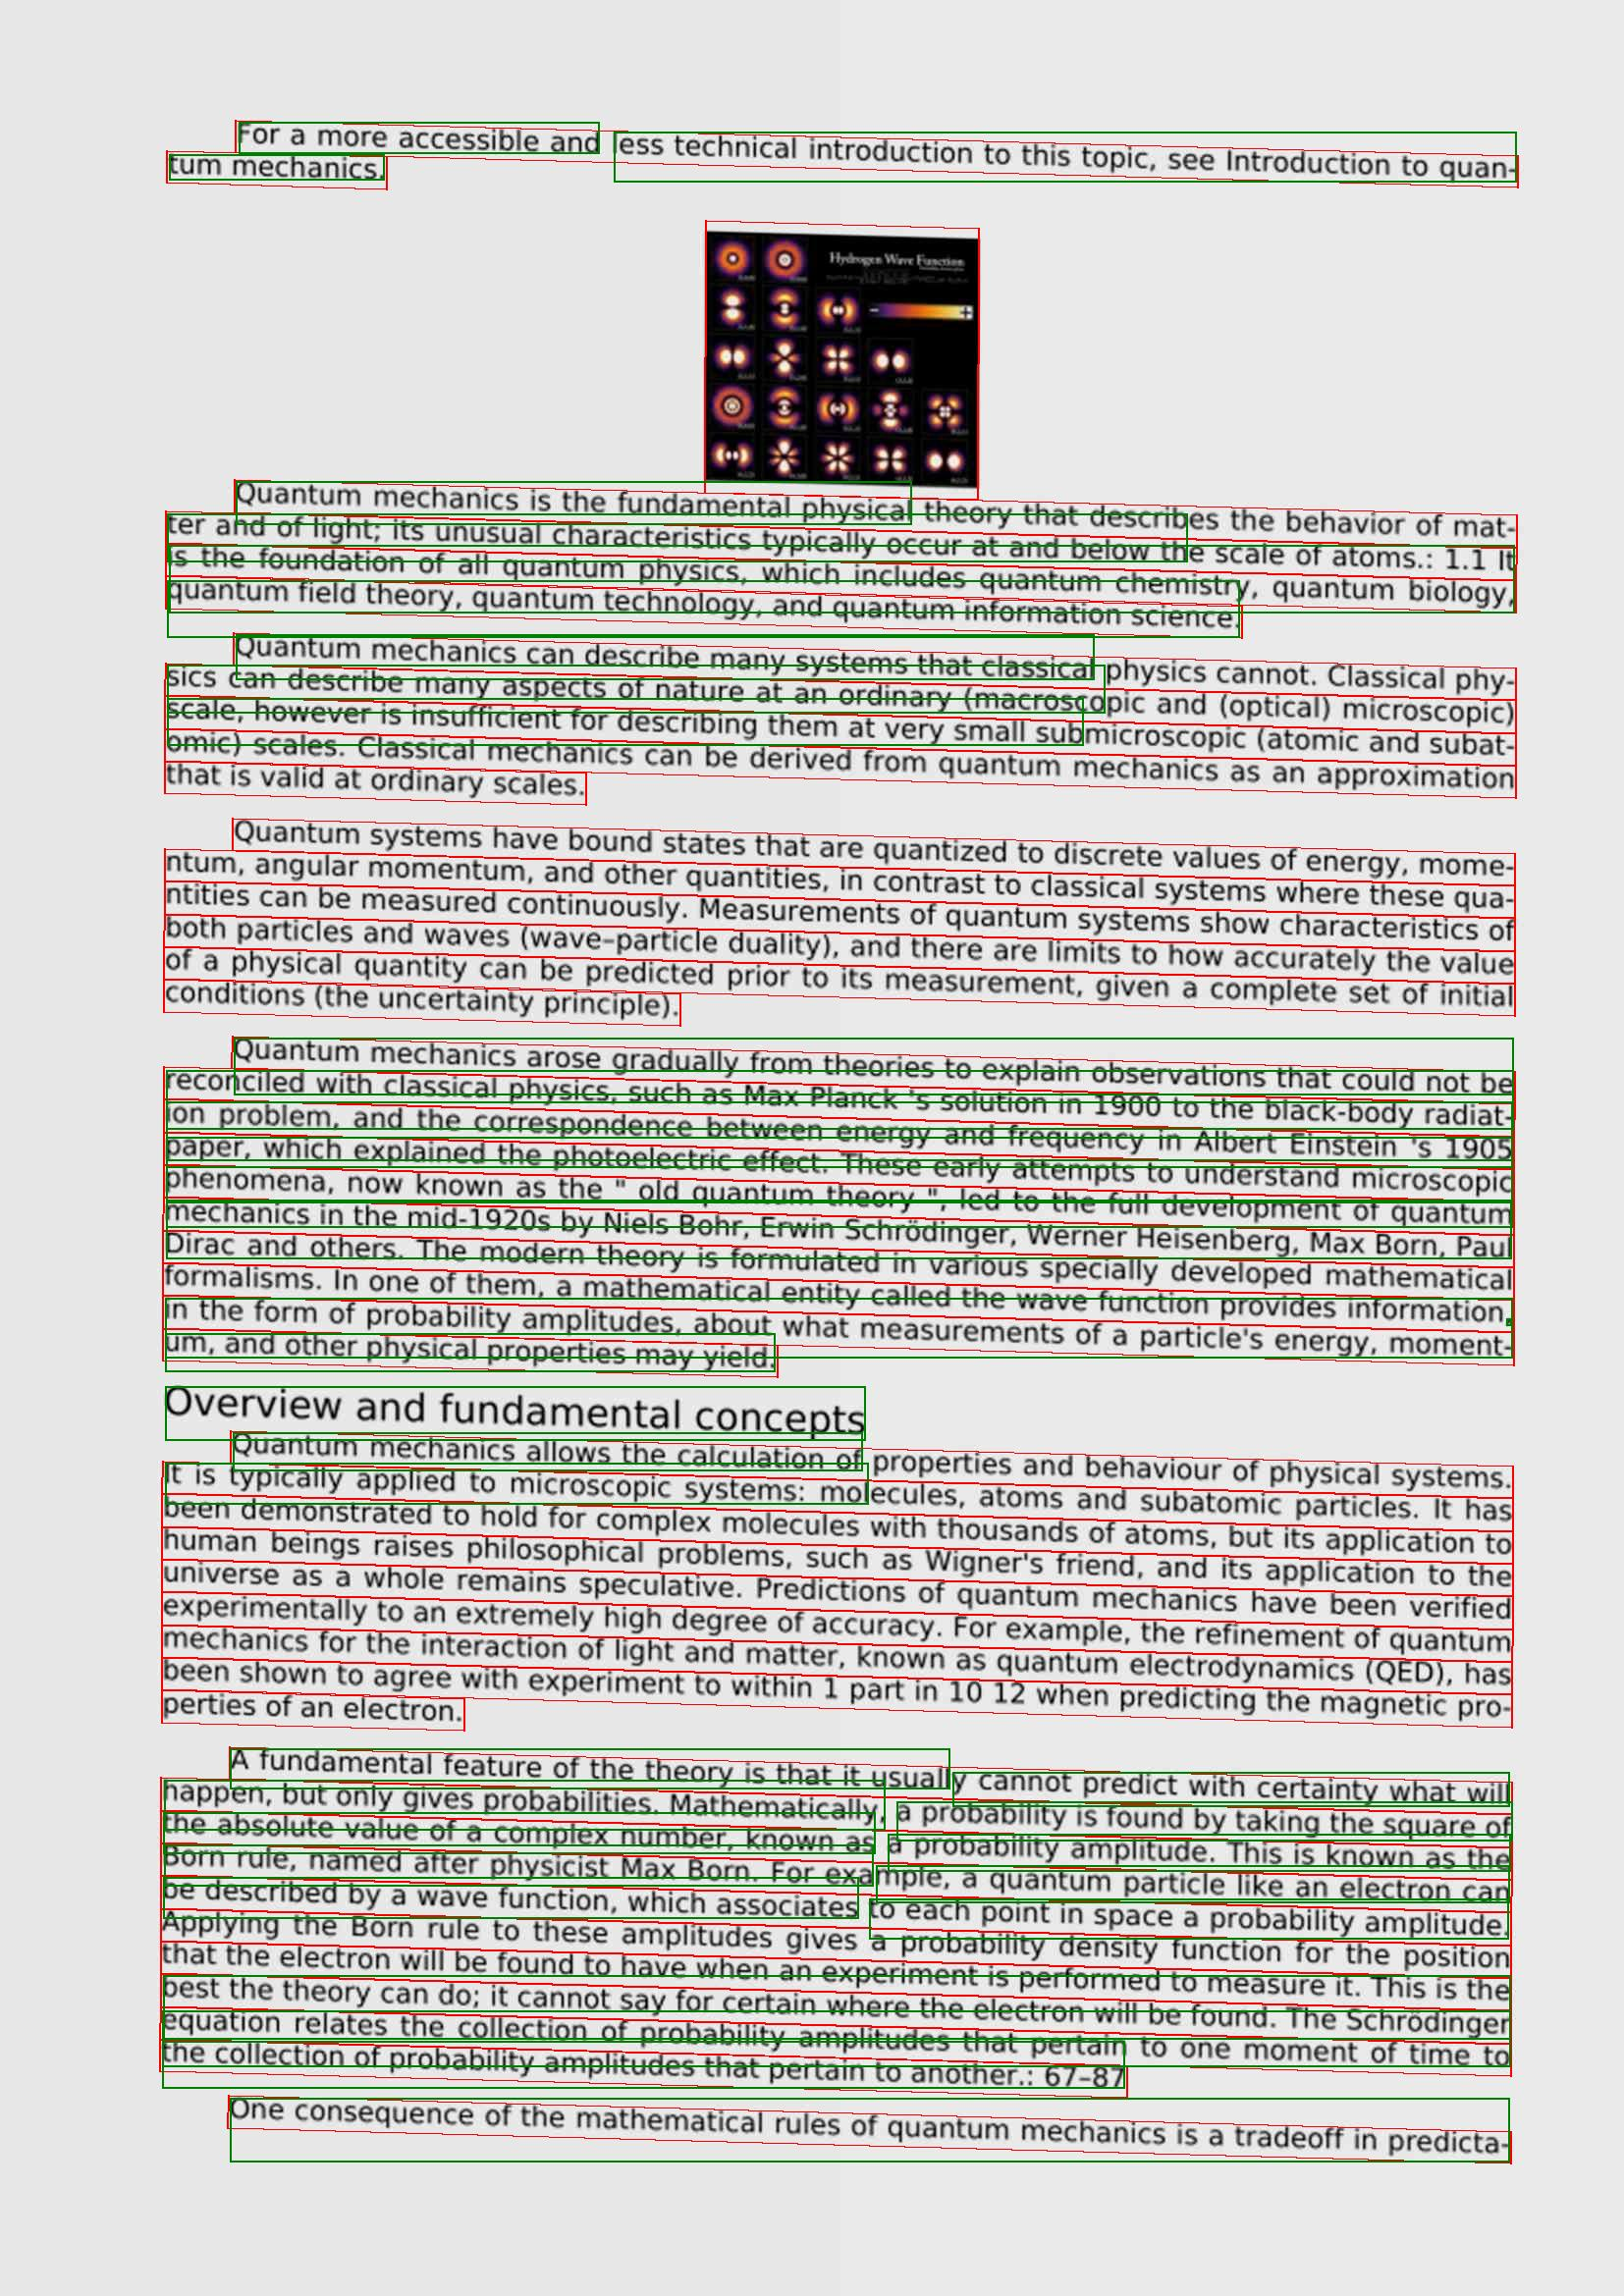

In [7]:
def iter_gt_elements(gt_json: dict) -> list[dict]:
    elements = []
    for page in gt_json.get("pages", []):
        for container in page.get("containers", []):
            elements.extend(container.get("elements", []))
    return elements or list(gt_json.get("elements", []))


def draw_quality_overlay(
    image_path: Path,
    gt_json: dict,
    predictions: list[dict],
    output_path: Path,
    draw_gt_polygons: bool = True,
    draw_gt_bboxes: bool = False,
    draw_ocr_bboxes: bool = True,
    line_width: int = 2,
) -> Path:
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    for element in iter_gt_elements(gt_json):
        if draw_gt_polygons and element.get("polygon"):
            points = [tuple(point) for point in element["polygon"]]
            draw.line(points + [points[0]], fill="red", width=line_width)

        if draw_gt_bboxes and element.get("bbox"):
            bbox = element["bbox"]
            x = float(bbox["x"])
            y = float(bbox["y"])
            draw.rectangle(
                [x, y, x + float(bbox["width"]), y + float(bbox["height"])],
                outline="blue",
                width=line_width,
            )

    if draw_ocr_bboxes:
        for line in predictions:
            bbox = line.get("bbox", {})
            if not bbox:
                continue
            x = float(bbox["x"])
            y = float(bbox["y"])
            draw.rectangle(
                [x, y, x + float(bbox["width"]), y + float(bbox["height"])],
                outline="green",
                width=line_width,
            )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    image.save(output_path)
    return output_path

overlay_path = draw_quality_overlay(
    SCAN_PATH,
    gt,
    ocr_lines,
    OVERLAY_PATH,
    draw_gt_polygons=True,
    draw_gt_bboxes=False,
    draw_ocr_bboxes=True,
)

print(f"Saved overlay: {overlay_path}")
display(IPyImage(filename=str(overlay_path)))

## 8. Optional: Draw Separate Debug Layers

Use these cells when the combined overlay is too visually dense. The separate outputs keep the same convention: red for GT polygons and green for Tesseract predictions.

In [8]:
gt_polygon_overlay = OVERLAY_PATH.with_name(f"{ARTIFACT_STEM}_gt_polygons.jpg")
ocr_bbox_overlay = OVERLAY_PATH.with_name(f"{ARTIFACT_STEM}_ocr_bboxes.jpg")

draw_quality_overlay(
    SCAN_PATH,
    gt,
    [],
    gt_polygon_overlay,
    draw_gt_polygons=True,
    draw_gt_bboxes=False,
    draw_ocr_bboxes=False,
)
draw_quality_overlay(
    SCAN_PATH,
    gt,
    ocr_lines,
    ocr_bbox_overlay,
    draw_gt_polygons=False,
    draw_gt_bboxes=False,
    draw_ocr_bboxes=True,
)

print("GT polygons:", gt_polygon_overlay)
print("OCR bboxes:", ocr_bbox_overlay)


GT polygons: e:\PolyDocBench\outputs\experiments\tesseract_quality\en\quantum_mechanics\simple_article\debug\page_001\medium_scan_0_gt_polygons.jpg
OCR bboxes: e:\PolyDocBench\outputs\experiments\tesseract_quality\en\quantum_mechanics\simple_article\debug\page_001\medium_scan_0_ocr_bboxes.jpg


## 9. Sanity Checks For Rotated Scans

Use this section to confirm that `medium_scan` or `heavy_scan` GT was actually transformed.


In [9]:
matrix = transform.get("matrix", [])
identity_matrix = [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]]
non_identity_transform = matrix != identity_matrix

elements = iter_gt_elements(gt)
polygon_count = sum(1 for element in elements if element.get("polygon"))
source_bbox_count = sum(1 for element in elements if element.get("metadata", {}).get("source_bbox"))

print("Transform matrix:", matrix)
print("Non-identity transform:", non_identity_transform)
print("Elements:", len(elements))
print("Elements with polygon:", polygon_count)
print("Elements with source_bbox:", source_bbox_count)

if NOISE_PROFILE in {"medium_scan", "heavy_scan"}:
    assert non_identity_transform, "Expected a non-identity transform for affine/rotation noise profile"

assert polygon_count == len(elements), "Expected every GT element to have transformed polygon geometry"
assert source_bbox_count == len(elements), "Expected every GT element to preserve source_bbox metadata"


Transform matrix: [[0.9996149637162974, -0.0036807355920723747, 32.76913802043535], [0.027747510058839957, 0.9996149637162974, -22.496890884870492]]
Non-identity transform: True
Elements: 48
Elements with polygon: 48
Elements with source_bbox: 48
